# HW11 Part A :: Image Classification using Vision Transformer

COSC 6373 -- Adam Nelson-Archer, 2140122

## Setup

In [1]:
import os
import time

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
from keras import ops

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("Keras:", keras.__version__)
print("TensorFlow:", tf.__version__)

Keras: 3.1.1
TensorFlow: 2.16.1


## 1. Prepare the dataset

### a. Load the Horses vs. Camels dataset
### b. Split the dataset into training, validation, and test sets (70/15/15)
### c. Preprocessing: Resize to 224x224, normalize pixel values

In [2]:
import kagglehub
from pathlib import Path

download_root = Path(kagglehub.dataset_download("akrsnv/horses-and-camels"))
print("Downloaded to:", download_root)

# Inspect the dataset directory
for p in sorted(download_root.rglob("*"))[:20]:
    print(p)

100%|██████████| 28.3M/28.3M [00:00<00:00, 33.0MB/s]

Extracting files...


Downloaded to: C:\Users\Adam\.cache\kagglehub\datasets\akrsnv\horses-and-camels\versions\2
C:\Users\Adam\.cache\kagglehub\datasets\akrsnv\horses-and-camels\versions\2\test
C:\Users\Adam\.cache\kagglehub\datasets\akrsnv\horses-and-camels\versions\2\test\camel
C:\Users\Adam\.cache\kagglehub\datasets\akrsnv\horses-and-camels\versions\2\test\camel\180.png
C:\Users\Adam\.cache\kagglehub\datasets\akrsnv\horses-and-camels\versions\2\test\camel\181.png
C:\Users\Adam\.cache\kagglehub\datasets\akrsnv\horses-and-camels\versions\2\test\camel\182.png
C:\Users\Adam\.cache\kagglehub\datasets\akrsnv\horses-and-camels\versions\2\test\camel\183.png
C:\Users\Adam\.cache\kagglehub\datasets\akrsnv\horses-and-camels\versions\2\test\camel\184.png
C:\Users\Adam\.cache\kagglehub\datasets\akrsnv\horses-and-camels\versions\2\test\camel\185.png
C:\Users\Adam\.cache\kagglehub\datasets\akrsnv\horses-and-camels\versions\2\test\camel\186.png
C:\Users\Adam\.cache\kagglehub\datasets\akrsnv\horses-and-camels\versions\2\

In [3]:
image_size = 224
batch_size = 32

# Load full dataset from directory
full_ds = tf.keras.utils.image_dataset_from_directory(
    download_root,
    image_size=(image_size, image_size),
    batch_size=None,
    label_mode="int",
    shuffle=True,
    seed=42,
)

class_names = full_ds.class_names
print("Classes:", class_names)
num_classes = len(class_names)

# Collect all images and labels into arrays
images = []
labels_list = []
for img, label in full_ds:
    images.append(img.numpy())
    labels_list.append(label.numpy())

images = np.array(images)
labels_arr = np.array(labels_list)
print(f"Total images: {len(images)}, shape: {images.shape}")

# Normalize pixel values to [0, 1]
images = images.astype("float32") / 255.0

Found 400 files belonging to 2 classes.
Classes: ['test', 'train']
Total images: 400, shape: (400, 224, 224, 3)


In [4]:
# Split: 70% train, 15% val, 15% test
from sklearn.model_selection import train_test_split

x_temp, x_test, y_temp, y_test = train_test_split(
    images, labels_arr, test_size=0.15, random_state=42, stratify=labels_arr
)

# Split the remaining 85% into train (70/85 ~ 82.35%) and val (15/85 ~ 17.65%)
x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp, test_size=15/85, random_state=42, stratify=y_temp
)

print(f"Train: {x_train.shape[0]} images")
print(f"Val:   {x_val.shape[0]} images")
print(f"Test:  {x_test.shape[0]} images")

Train: 279 images
Val:   61 images
Test:  60 images


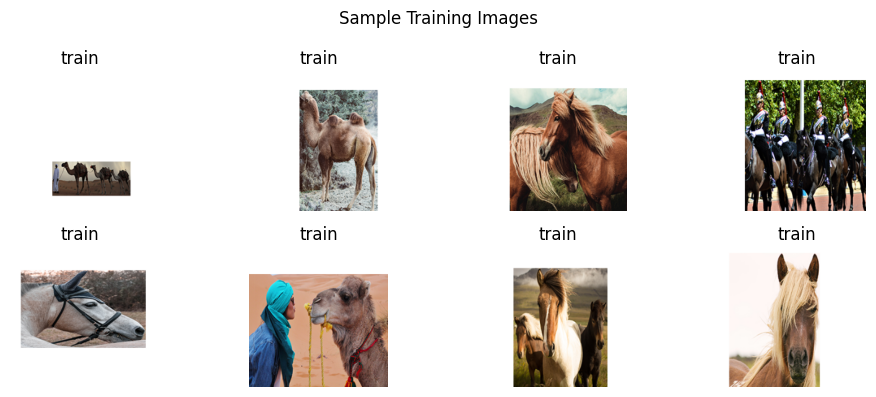

In [5]:
# Visualize a few samples
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

## 2. Build the ViT model

Using the provided Keras starter code. No pretrained weights -- model is initialized from scratch.

### Configure hyperparameters

These training settings will be reused for the CNN in Part B to ensure a fair comparison.

In [6]:
# --- Training settings (shared with CNN in Part B) ---
learning_rate = 0.001
weight_decay = 0.0001
num_epochs = 20

# --- ViT-specific hyperparameters ---
patch_size = 16
num_patches = (image_size // patch_size) ** 2  # 196 patches for 224x224 with patch 16
projection_dim = 64
num_heads = 4
transformer_units = [
    projection_dim * 2,
    projection_dim,
]
transformer_layers = 8
mlp_head_units = [
    2048,
    1024,
]

input_shape = (image_size, image_size, 3)

print(f"Image size: {image_size}x{image_size}")
print(f"Patch size: {patch_size}x{patch_size}")
print(f"Number of patches: {num_patches}")
print(f"Projection dim: {projection_dim}")

Image size: 224x224
Patch size: 16x16
Number of patches: 196
Projection dim: 64


### Data augmentation

In [7]:
data_augmentation = keras.Sequential(
    [
        layers.Normalization(),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)

# Compute the mean and the variance of the training data for normalization.
data_augmentation.layers[0].adapt(x_train)

### Implement multilayer perceptron (MLP)

In [8]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

### Implement patch creation as a layer

In [9]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

Image size: 224 X 224
Patch size: 16 X 16
Patches per image: 196
Elements per patch: 768


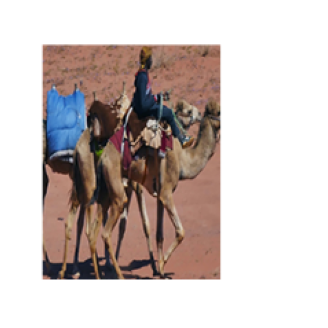

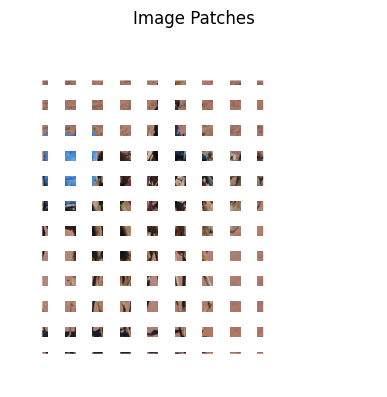

In [10]:
# Display patches for a sample image
plt.figure(figsize=(4, 4))
image = x_train[np.random.choice(range(x_train.shape[0]))]
plt.imshow(image)
plt.axis("off")

resized_image = ops.image.resize(
    ops.convert_to_tensor([image]), size=(image_size, image_size)
)
patches = Patches(patch_size)(resized_image)
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")

n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = ops.reshape(patch, (patch_size, patch_size, 3))
    plt.imshow(ops.convert_to_numpy(patch_img))
    plt.axis("off")
plt.suptitle("Image Patches")
plt.tight_layout()
plt.show()

### Implement the patch encoding layer

In [11]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config

### Build the ViT model

The model includes:
- Patch extraction
- Patch embedding
- Transformer encoder layers
- Classification head

In [12]:
def create_vit_classifier():
    inputs = keras.Input(shape=input_shape)
    # Augment data.
    augmented = data_augmentation(inputs)
    # Create patches.
    patches = Patches(patch_size)(augmented)
    # Encode patches.
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    # Classify outputs.
    logits = layers.Dense(num_classes)(features)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model

vit_classifier = create_vit_classifier()
vit_classifier.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          7 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_1 (Patches) │ (None, 196, 768)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 196, 64)   │     61,760 │ patches_1[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 64)   │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 196, 128)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 64)   │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 196, 64)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 64)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 196, 128)  │          0 │ dense_3[0][0]   

 Total params: 28,519,881 (108.79 MB)

 Trainable params: 28,519,874 (108.79 MB)

 Non-trainable params: 7 (32.00 B)

## 3. Train the model

### 4. Training settings (shared with CNN in Part B)
- Batch size: 32
- Epochs: 20
- Optimizer: AdamW
- Learning rate: 0.001

### 5. Record training time

In [13]:
optimizer = keras.optimizers.AdamW(
    learning_rate=learning_rate, weight_decay=weight_decay
)

vit_classifier.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
    ],
)

checkpoint_filepath = "vit_checkpoint.weights.h5"
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    checkpoint_filepath,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
)

# Record start time
start_time = time.time()

history = vit_classifier.fit(
    x=x_train,
    y=y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_data=(x_val, y_val),
    callbacks=[checkpoint_callback],
)

# Record end time
end_time = time.time()
training_duration = end_time - start_time

print(f"\nTraining start time: {time.strftime('%H:%M:%S', time.localtime(start_time))}")
print(f"Training end time:   {time.strftime('%H:%M:%S', time.localtime(end_time))}")
print(f"Total training duration: {training_duration:.2f} seconds ({training_duration/60:.2f} minutes)")

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.7440 - loss: 3.8630 - val_accuracy: 0.9016 - val_loss: 3.4236
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8423 - loss: 4.5643 - val_accuracy: 0.8689 - val_loss: 4.3489
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 985ms/step - accuracy: 0.8149 - loss: 6.9433 - val_accuracy: 0.8525 - val_loss: 1.5761
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 856ms/step - accuracy: 0.9103 - loss: 1.8754 - val_accuracy: 0.3607 - val_loss: 2.1140
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 827ms/step - accuracy: 0.7576 - loss: 2.2784 - val_accuracy: 0.8689 - val_loss: 1.2014
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 780ms/step - accuracy: 0.8491 - loss: 1.2508 - val_accuracy: 0.7377 - val_loss: 0.8938
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7748 - loss: 1.3382 - val_accuracy: 0.9016 - val_loss: 1.1285
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 869ms/step - accuracy: 0.8422 - loss: 1.2494 - val_accuracy: 0.8689 - val_loss: 0.

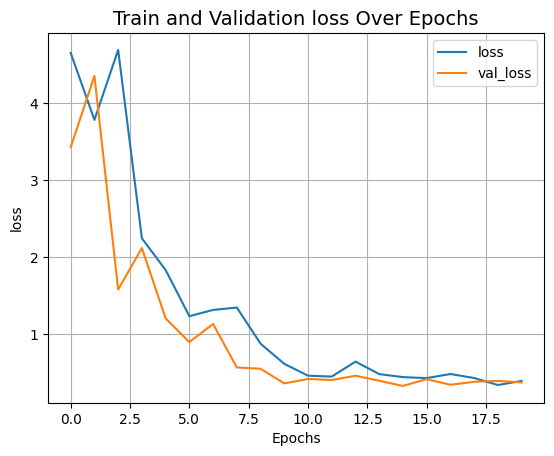

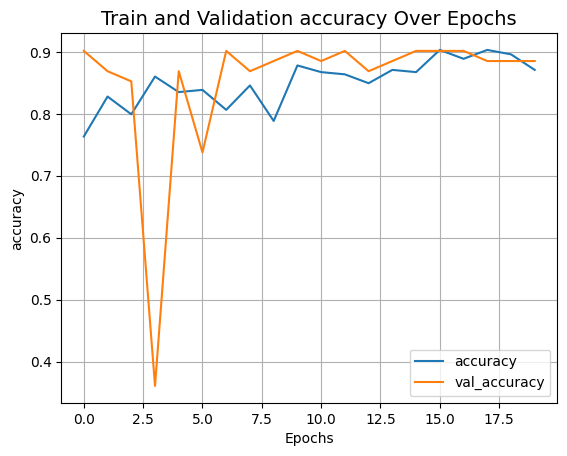

In [14]:
# Load the best checkpoint weights
vit_classifier.load_weights(checkpoint_filepath)

def plot_history(history, item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

plot_history(history, "loss")
plot_history(history, "accuracy")

## Acknowledgment

I used a GPT-5.3-Codex to help scaffold and organize this notebook.

Gemini-3.1 was used to check the result and validate conformity with the assignment outline.

All observations and responses were written by me, Adam Nelson-Archer.